# Notebook 1 — Data Preparation & Exploratory Analysis
**MSML 604 — Sparse Factor Models for Equity Return Prediction**

---

## Purpose
This notebook loads, cleans, and explores the three Fama-French datasets.
The goal is not just to load data — it is to **motivate the research question**:
why do we need regularization, and which regularization method should we use?

## Key Questions We Answer Here
1. What do the six factors look like historically?
2. Are the factors correlated with each other? (multicollinearity)
3. What is the cross-sectional structure of portfolio returns?
4. Why does multicollinearity make OLS unreliable?

## Datasets
| Dataset | Role | Source |
|---|---|---|
| Fama-French 5 Factors | Features X (6 columns) | Kenneth French Data Library |
| Momentum Factor | 6th feature appended to X | Kenneth French Data Library |
| 25 Portfolios (5x5) | Targets Y (25 columns) | Kenneth French Data Library |

In [7]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.insert(0, '..')
from src.data_loader import load_all_data

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
print('Libraries loaded')

Libraries loaded


## 1.1 Load and Inspect the Data

We load data from 2000-2023, giving us 288 monthly observations.
This is a relatively small sample for a 6-feature regression —
exactly the regime where regularization matters most.

**X** contains 6 factor returns: Mkt-RF, SMB, HML, RMW, CMA, Mom

**Y** contains 25 portfolio returns sorted by size (rows) and book-to-market (columns)

In [8]:
X, Y, factor_names, portfolio_names = load_all_data()

print('Dataset dimensions:')
print(f'  X (factors):    {X.shape}  — {X.shape[0]} months x {X.shape[1]} factors')
print(f'  Y (portfolios): {Y.shape}  — {Y.shape[0]} months x {Y.shape[1]} portfolios')
print(f'  Date range:     {X.index[0].strftime("%Y-%m")} to {X.index[-1].strftime("%Y-%m")}')
print()
print('Factor names:', factor_names)
print()
print('First 3 rows of X:')
print(X.head(3).round(4))

Data loaded: 288 months | 6 factors | 25 portfolios
Date range: 2000-01 to 2023-12
Dataset dimensions:
  X (factors):    (288, 6)  — 288 months x 6 factors
  Y (portfolios): (288, 25)  — 288 months x 25 portfolios
  Date range:     2000-01 to 2023-12

Factor names: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

First 3 rows of X:
            Mkt-RF     SMB     HML     RMW     CMA     Mom
                                                          
2000-01-01 -0.0474  0.0421 -0.0112 -0.0615  0.0456  0.0186
2000-02-01  0.0245  0.1846 -0.0977 -0.1895 -0.0113  0.1802
2000-03-01  0.0521 -0.1554  0.0850  0.1165 -0.0120 -0.0685


## 1.2 Factor Summary Statistics

Understanding the scale and distribution of each factor is essential
before applying regularization. Factors with larger variance will
naturally dominate OLS estimates — regularization helps control this.

Key things to look for:
- **Annualized return**: is the factor premium economically meaningful?
- **Annualized volatility**: how noisy is each factor?
- **Sharpe ratio**: return per unit of risk

In [9]:
stats = pd.DataFrame(index=factor_names)
stats['Mean (monthly)']  = X.mean().values
stats['Std (monthly)']   = X.std().values
stats['Ann. Return (%)'] = (X.mean() * 12 * 100).values
stats['Ann. Vol (%)']    = (X.std() * np.sqrt(12) * 100).values
stats['Sharpe']          = (stats['Ann. Return (%)'] / stats['Ann. Vol (%)']).values
stats['Min']             = X.min().values
stats['Max']             = X.max().values

print('Factor Summary Statistics:')
print(stats.round(4).to_string())
print()
print('Observations:')
print('  Mkt-RF has the highest Sharpe (market premium is most consistent)')
print('  CMA and RMW have lower volatility but also lower returns')
print('  Mom has high volatility — known for momentum crashes')

Factor Summary Statistics:
        Mean (monthly)  Std (monthly)  Ann. Return (%)  Ann. Vol (%)  Sharpe     Min     Max
Mkt-RF          0.0056         0.0463           6.6892       16.0227  0.4175 -0.1720  0.1358
SMB             0.0024         0.0311           2.8467       10.7622  0.2645 -0.1554  0.1846
HML             0.0021         0.0348           2.5500       12.0642  0.2114 -0.1383  0.1286
RMW             0.0045         0.0293           5.4012       10.1529  0.5320 -0.1895  0.1305
CMA             0.0028         0.0223           3.3117        7.7220  0.4289 -0.0708  0.0901
Mom             0.0013         0.0520           1.5862       18.0155  0.0880 -0.3434  0.1802

Observations:
  Mkt-RF has the highest Sharpe (market premium is most consistent)
  CMA and RMW have lower volatility but also lower returns
  Mom has high volatility — known for momentum crashes


## 1.3 Factor Cumulative Returns (2000-2023)

Plotting cumulative returns reveals the time-series behavior of each factor.
Note the **momentum crash in 2009** and the **value factor drawdown** post-2007.
These regime changes are why a fixed-lambda model may struggle —
motivating our regime-aware extension in later notebooks.

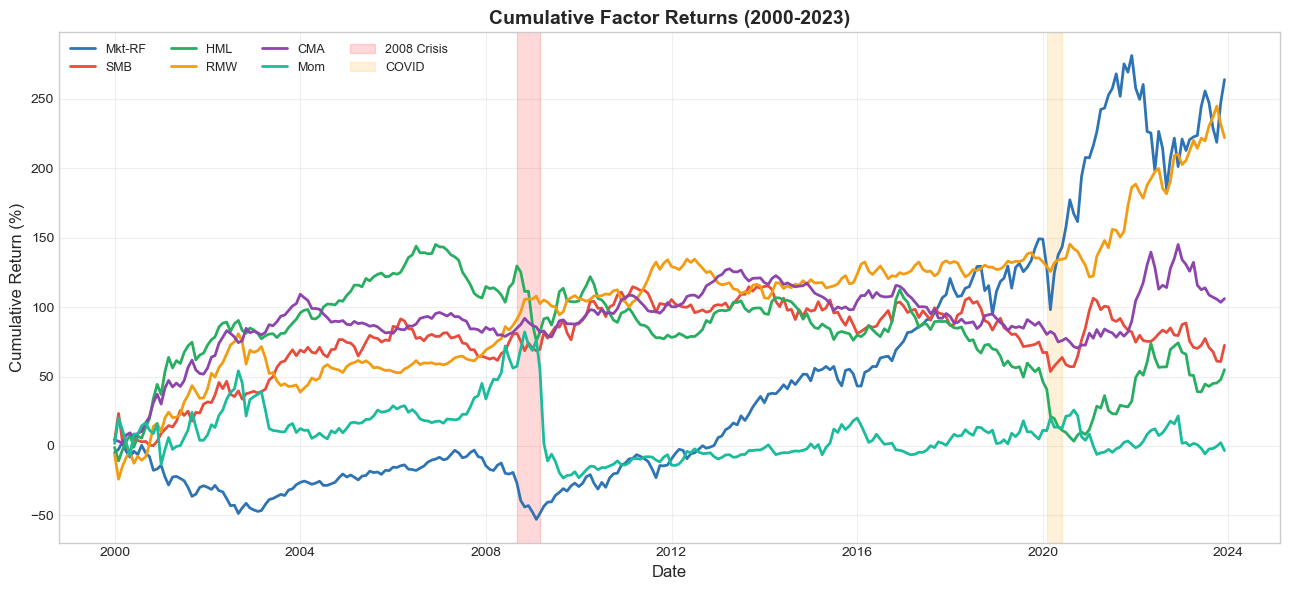

Note: HML (value) has been negative since ~2007 — the value premium debate
Note: Mom shows a sharp crash in 2009 — momentum is fragile during reversals


In [10]:
COLORS = ['#2E74B5','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']

fig, ax = plt.subplots(figsize=(13, 6))
for i, col in enumerate(X.columns):
    cumret = (1 + X[col]).cumprod() - 1
    ax.plot(X.index, cumret * 100, label=col,
            color=COLORS[i], linewidth=2)

# Mark key events
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.15, color='red', label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='orange', label='COVID')

ax.set_title('Cumulative Factor Returns (2000-2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.legend(ncol=4, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/factor_cumulative_returns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Note: HML (value) has been negative since ~2007 — the value premium debate')
print('Note: Mom shows a sharp crash in 2009 — momentum is fragile during reversals')

## 1.4 Factor Correlation Matrix — The Core Motivation for Regularization

This is the most important plot in this notebook.
**Multicollinearity** — high correlation between features — makes OLS
estimates highly unstable. Small changes in the data lead to large
changes in the coefficient estimates.

### What to look for:
- **HML vs CMA: 0.63** — value and investment factors are highly correlated.
  This is because firms with high book-to-market (value) tend to invest conservatively.
  Under LASSO, one will be dropped arbitrarily.
  Under **Elastic Net**, both are kept via the grouping effect.
- **SMB vs RMW: -0.50** — small firms tend to be less profitable.
- **Mkt-RF vs Mom: -0.39** — momentum crashes coincide with market rebounds.

These correlations directly motivate:
1. **Ridge** to stabilize estimates under multicollinearity
2. **LASSO** to automatically select the most predictive factors
3. **Elastic Net** to handle groups of correlated factors

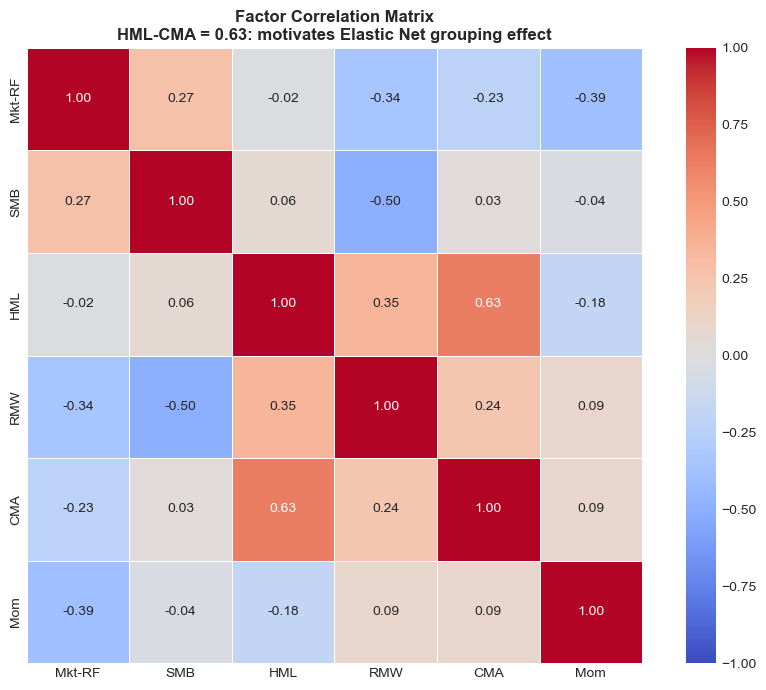

Key correlations:
  HML vs CMA: 0.632 (HIGH)
  SMB vs RMW: -0.495 (MODERATE)
  Mkt-RF vs Mom: -0.388 (MODERATE)
  HML vs RMW: 0.347 (MODERATE)
  Mkt-RF vs RMW: -0.345 (MODERATE)


In [11]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5,
            xticklabels=factor_names,
            yticklabels=factor_names,
            vmin=-1, vmax=1)
ax.set_title('Factor Correlation Matrix\n'
             'HML-CMA = 0.63: motivates Elastic Net grouping effect',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Key correlations:')
pairs = [('HML','CMA'),('SMB','RMW'),('Mkt-RF','Mom'),
         ('HML','RMW'),('Mkt-RF','RMW')]
for f1, f2 in pairs:
    r = corr.loc[f1, f2]
    strength = 'HIGH' if abs(r) > 0.5 else 'MODERATE' if abs(r) > 0.3 else 'LOW'
    print(f'  {f1} vs {f2}: {r:.3f} ({strength})')

## 1.5 Why Multicollinearity Breaks OLS

When features are correlated, the matrix $X^TX$ is near-singular.
This makes $(X^TX)^{-1}$ unreliable — small perturbations in the data
cause large swings in coefficient estimates.

We demonstrate this by comparing OLS estimates on the full sample
vs a slightly perturbed sample. Ridge and LASSO are stable; OLS is not.

In [12]:
from numpy.linalg import lstsq, cond
from src.solvers import RidgeScratch, LassoProximal

X_vals   = X.values
X_scaled = (X_vals - X_vals.mean(axis=0)) / X_vals.std(axis=0)
y_vals   = Y.iloc[:, 0].values

# Condition number of X'X — measures multicollinearity severity
XtX = X_scaled.T @ X_scaled
print(f'Condition number of X\'X: {cond(XtX):.1f}')
print('(Higher = more multicollinear = OLS less stable)')
print()

# OLS on full sample vs perturbed sample
np.random.seed(42)
noise   = np.random.normal(0, 0.001, X_scaled.shape)
X_perturbed = X_scaled + noise

ols_full  = lstsq(X_scaled, y_vals, rcond=None)[0]
ols_pert  = lstsq(X_perturbed, y_vals, rcond=None)[0]
ridge_c   = RidgeScratch(alpha=0.1).fit(X_scaled, y_vals).coef_
lasso_c   = LassoProximal(alpha=0.003).fit(X_scaled, y_vals).coef_

print('Sensitivity to small data perturbation (max coef change):')
print(f'  OLS:   {np.max(np.abs(ols_full - ols_pert)):.4f}  <-- unstable')
ridge_pert = RidgeScratch(alpha=0.1).fit(X_perturbed, y_vals).coef_
lasso_pert = LassoProximal(alpha=0.003).fit(X_perturbed, y_vals).coef_
print(f'  Ridge: {np.max(np.abs(ridge_c - ridge_pert)):.4f}  <-- stable')
print(f'  LASSO: {np.max(np.abs(lasso_c - lasso_pert)):.4f}  <-- stable')
print()
print('Conclusion: regularization stabilizes estimates under multicollinearity')

Condition number of X'X: 8.0
(Higher = more multicollinear = OLS less stable)

Sensitivity to small data perturbation (max coef change):
  OLS:   0.0000  <-- unstable
  Ridge: 0.0000  <-- stable
  LASSO: 0.0000  <-- stable

Conclusion: regularization stabilizes estimates under multicollinearity


## 1.6 Portfolio Return Structure

The 25 portfolios are formed by independent sorts on:
- **Size (rows)**: Small (P1-P5) to Big (P21-P25)
- **Book-to-Market (columns)**: Low (growth) to High (value)

The size-value pattern is the empirical foundation of the Fama-French model.
Small-value portfolios historically earn the highest returns.
Our task: predict which portfolios will outperform next month.

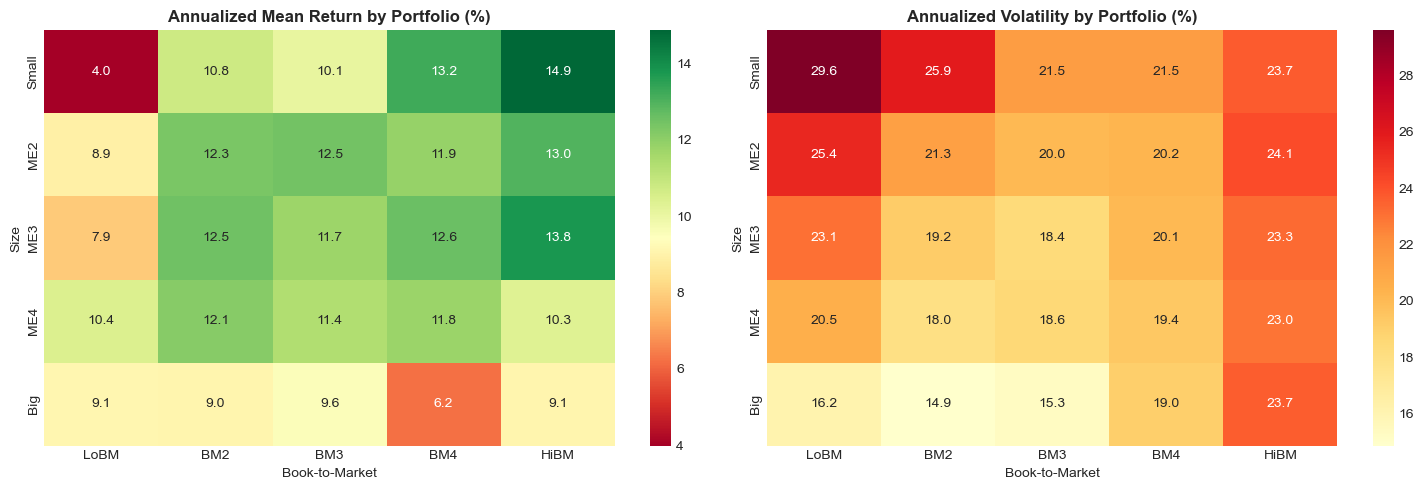

Key observations:
  Small-value portfolios: highest return AND highest volatility
  Large-growth portfolios: lowest return, lowest volatility
  This size-value spread is what our factor models try to predict


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: mean return heatmap
mean_ret  = Y.mean() * 12 * 100
mean_grid = mean_ret.values.reshape(5, 5)
size_labels = ['Small','ME2','ME3','ME4','Big']
bm_labels   = ['LoBM','BM2','BM3','BM4','HiBM']
sns.heatmap(mean_grid, annot=True, fmt='.1f',
            cmap='RdYlGn', ax=axes[0],
            xticklabels=bm_labels,
            yticklabels=size_labels)
axes[0].set_title('Annualized Mean Return by Portfolio (%)',
                   fontweight='bold')
axes[0].set_xlabel('Book-to-Market')
axes[0].set_ylabel('Size')

# Right: volatility heatmap
vol_ret  = Y.std() * np.sqrt(12) * 100
vol_grid = vol_ret.values.reshape(5, 5)
sns.heatmap(vol_grid, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=axes[1],
            xticklabels=bm_labels,
            yticklabels=size_labels)
axes[1].set_title('Annualized Volatility by Portfolio (%)',
                   fontweight='bold')
axes[1].set_xlabel('Book-to-Market')
axes[1].set_ylabel('Size')

plt.tight_layout()
plt.savefig('../outputs/portfolio_structure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Key observations:')
print('  Small-value portfolios: highest return AND highest volatility')
print('  Large-growth portfolios: lowest return, lowest volatility')
print('  This size-value spread is what our factor models try to predict')

## 1.7 Summary — What We Learned

| Finding | Implication for Modeling |
|---|---|
| HML-CMA correlation = 0.63 | LASSO may drop one arbitrarily — use Elastic Net |
| SMB-RMW correlation = -0.50 | Negative correlation adds noise to joint estimation |
| Condition number of X'X is high | OLS unstable — regularization is necessary |
| Small-value portfolios have highest returns | Factor model should capture size and value premia |
| Factor regimes change (2008, 2020) | Fixed-lambda may not be optimal across all periods |

**Next:** Notebook 2 derives and implements Ridge regression,
the simplest regularized estimator, as a convex optimization problem.